# SEEG Predictability - All MOIs

In [1]:
import pandas as pd

## Load CSV Data

In [3]:
df = pd.read_csv('../data/df_results/ieeg_metrics/df_cross_metric_predictability_ALL_MOIs.csv')

In [4]:
df.head(10)

,Unnamed: 0,sub,run_is,pre_metric,post_metric,pre_metric_label,post_metric_label,n_trials,within_sample_corr,oos_r2,oos_r2_std,oos_corr,oos_corr_std,is_diagonal
0,0,1,1,mean_data,mean_data,Mean Data,Mean Data,40,-0.232231,-0.095787,0.127075,0.268280,0.111492,True
1,1,1,1,mean_data,var_data,Mean Data,Var Data,40,-0.160229,-0.366549,0.370065,0.172000,0.092679,False
2,2,1,1,mean_data,mean_var_data,Mean Data,Mean Var Data,40,-0.089715,-0.371416,0.159801,-0.178743,0.037199,False
3,3,1,1,mean_data,var_mean_data,Mean Data,Var Mean Data,40,-0.158329,-0.486368,0.483914,0.169795,0.102997,False
4,4,1,1,mean_data,var_var_data,Mean Data,Var Var Data,40,-0.131063,-1.642327,1.526281,0.160756,0.102897,False
5,5,1,1,mean_data,mean_skewness_data,Mean Data,Mean Skewness Data,40,0.194949,-0.388883,0.163787,0.135954,0.032140,False
6,6,1,1,mean_data,var_skewness_data,Mean Data,Var Skewness Data,40,-0.241407,-0.180177,0.044648,-0.166098,0.162963,False
7,7,1,1,mean_data,mean_kurt_data,Mean Data,Mean Kurt Data,40,-0.260536,-0.119598,0.017728,0.203918,0.169746,False
8,8,1,1,mean_data,var_kurt_data,Mean Data,Var Kurt Data,40,-0.185650,-0.035594,0.011475,0.186695,0.178208,False
9,9,1,1,mean_data,mean_peak_to_peak,Mean Data,Mean Peak To Peak,40,-0.091987,-0.395948,0.045473,-0.312117,0.012411,False


## Create Metrics x Metrics Matrix
Calculate average oos_r2 for each metric pair across all sessions and subjects.

In [5]:
# Group by pre_metric and post_metric, calculate mean oos_r2
metric_pairs = df.groupby(['pre_metric', 'post_metric'])['oos_r2'].mean().reset_index()

# Create pivot table with pre_metric as rows and post_metric as columns
metrics_matrix = metric_pairs.pivot(index='pre_metric', columns='post_metric', values='oos_r2')

print("Metrics x Metrics Matrix (Average OOS R2):")
print(metrics_matrix)

Metrics x Metrics Matrix (Average OOS R2):
post_metric         Dimensionality   Entropy_AEC   Entropy_COKU   Entropy_DFC  \
pre_metric                                                                      
Dimensionality           -0.298121 -2.586307e-01      -0.292823 -2.460178e-01   
Entropy_AEC              -0.306695 -1.678192e-01      -0.261667 -1.568769e-01   
Entropy_COKU             -0.301440 -3.016695e-01      -0.306502 -3.005765e-01   
Entropy_DFC              -0.347711 -1.877803e-01      -0.308059 -1.782387e-01   
Entropy_FC               -0.334138 -1.984917e-01      -0.309213 -1.948177e-01   
...                            ...           ...            ...           ...   
var_mean_data            -8.866788 -6.330530e+00      -6.780857 -2.404843e+00   
var_peak_to_peak         -4.510878 -9.131288e+00      -4.802074 -5.963434e+00   
var_skewness_data        -0.356865 -2.664946e-01      -0.335742 -2.560239e-01   
var_var_data        -278707.961656 -2.372135e+06 -691729.695643 -1

## Plot Heatmap
Visualize the metrics matrix as a heatmap using seaborn and matplotlib.

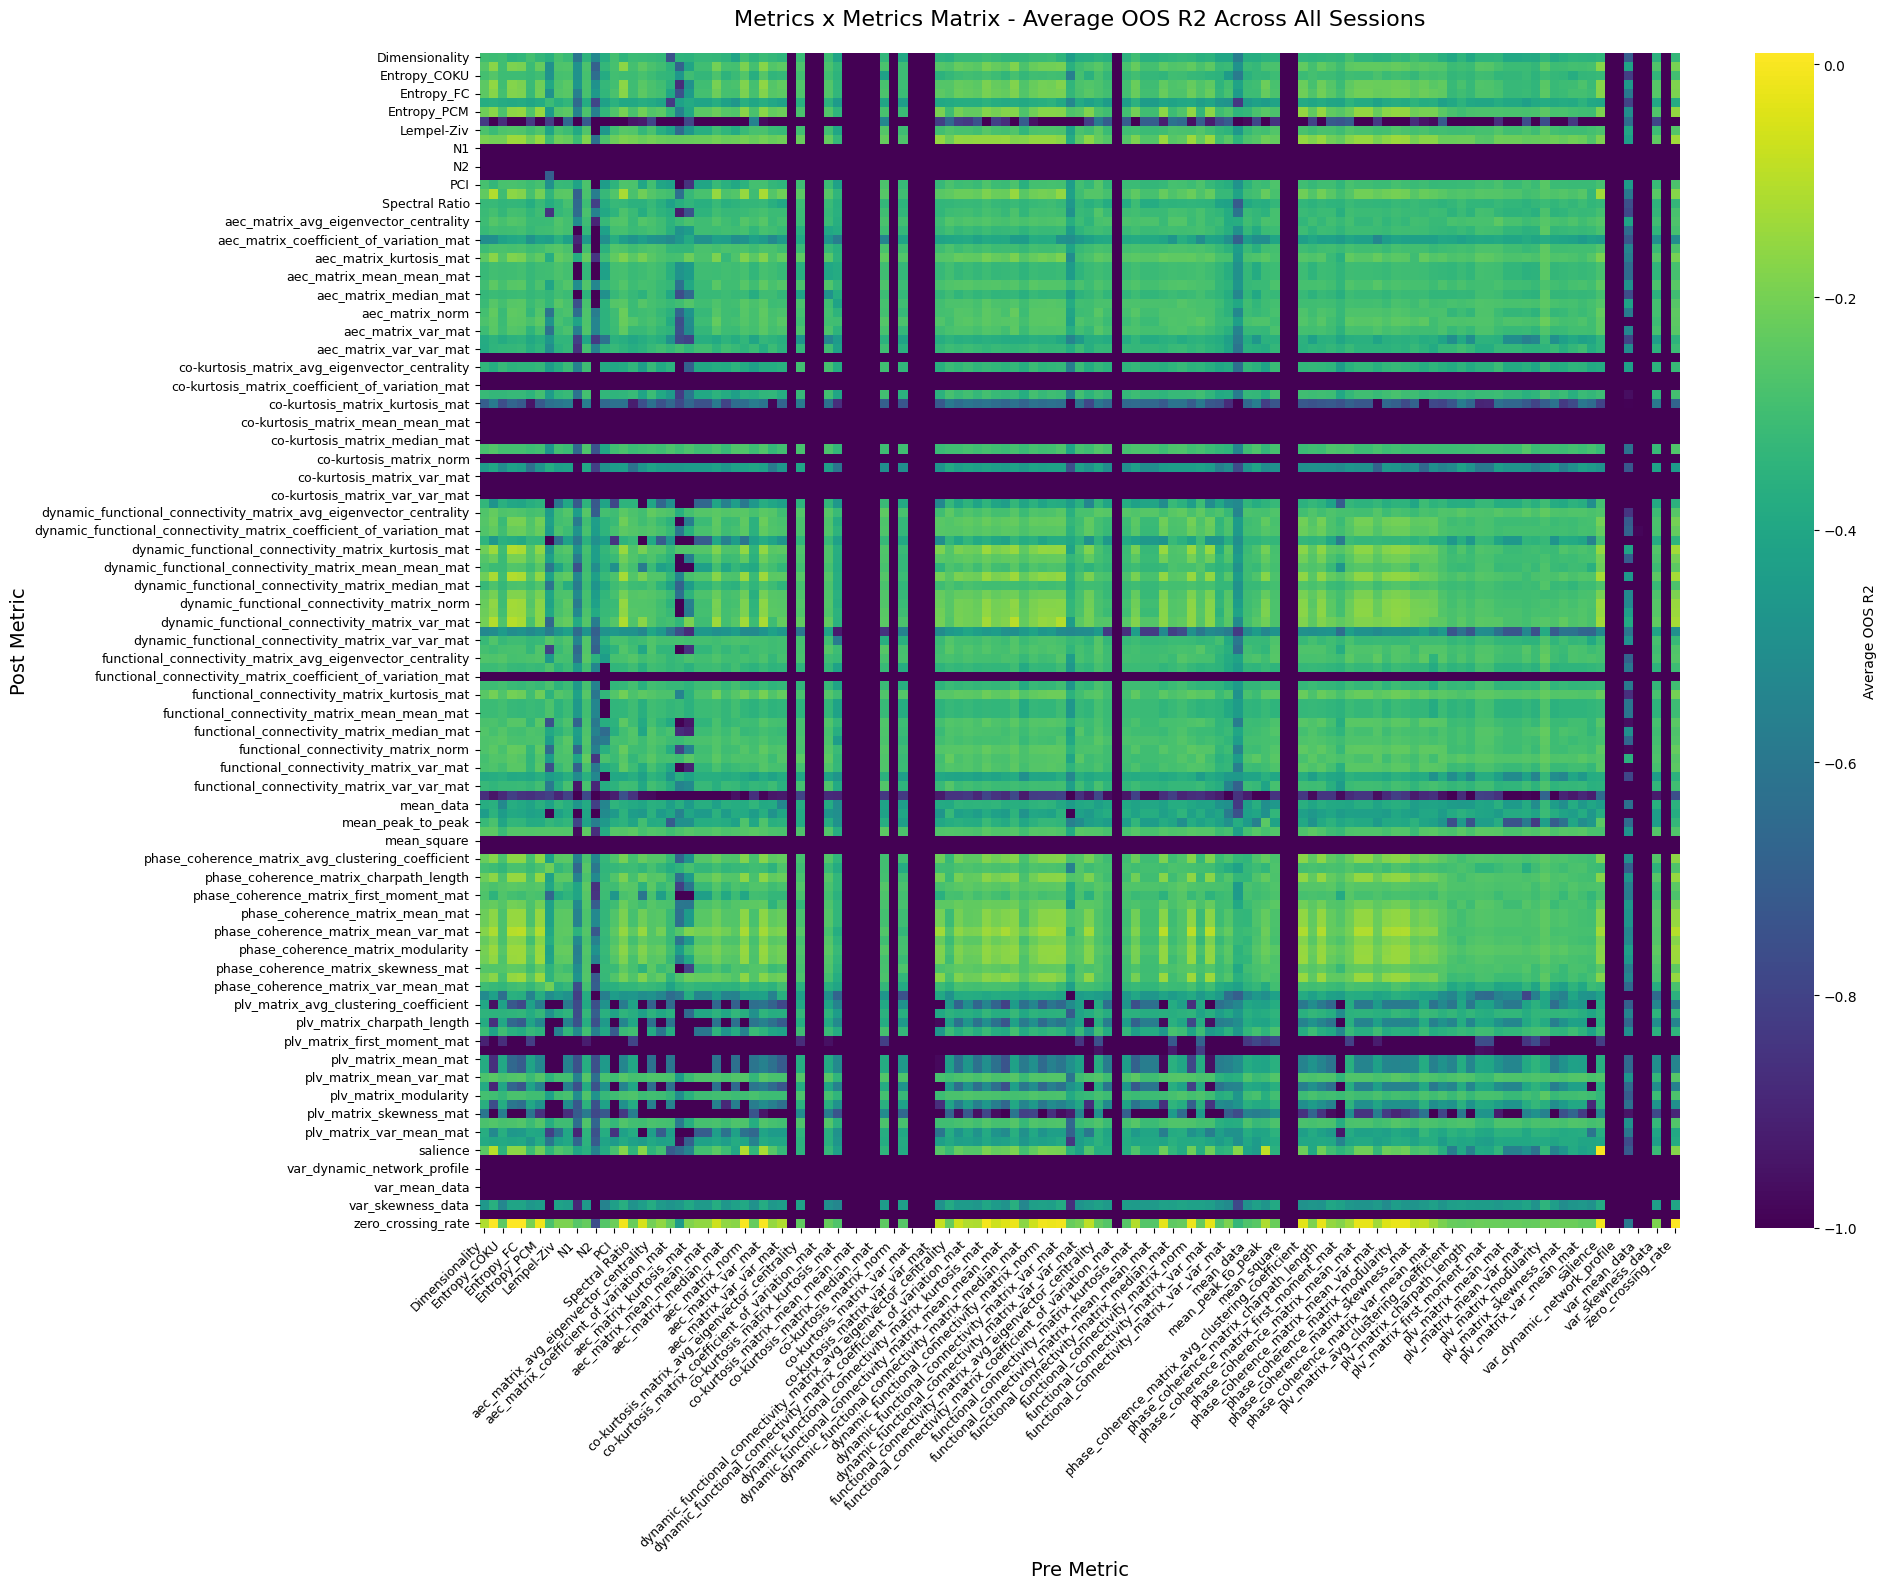

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create figure with appropriate size
plt.figure(figsize=(20, 16))

# Transpose matrix so pre_metric is on x-axis and post_metric is on y-axis
metrics_matrix_transposed = metrics_matrix.T

# Create heatmap
sns.heatmap(metrics_matrix_transposed, cmap='viridis', 
            cbar_kws={'label': 'Average OOS R2'},vmin=-1,vmax=0.01)

plt.title('Metrics x Metrics Matrix - Average OOS R2 Across All Sessions', fontsize=16, pad=20)
plt.xlabel('Pre Metric', fontsize=14)
plt.ylabel('Post Metric', fontsize=14)
plt.xticks(fontsize=9, rotation=45, ha='right')
plt.yticks(fontsize=9, rotation=0)
plt.tight_layout()
plt.show()

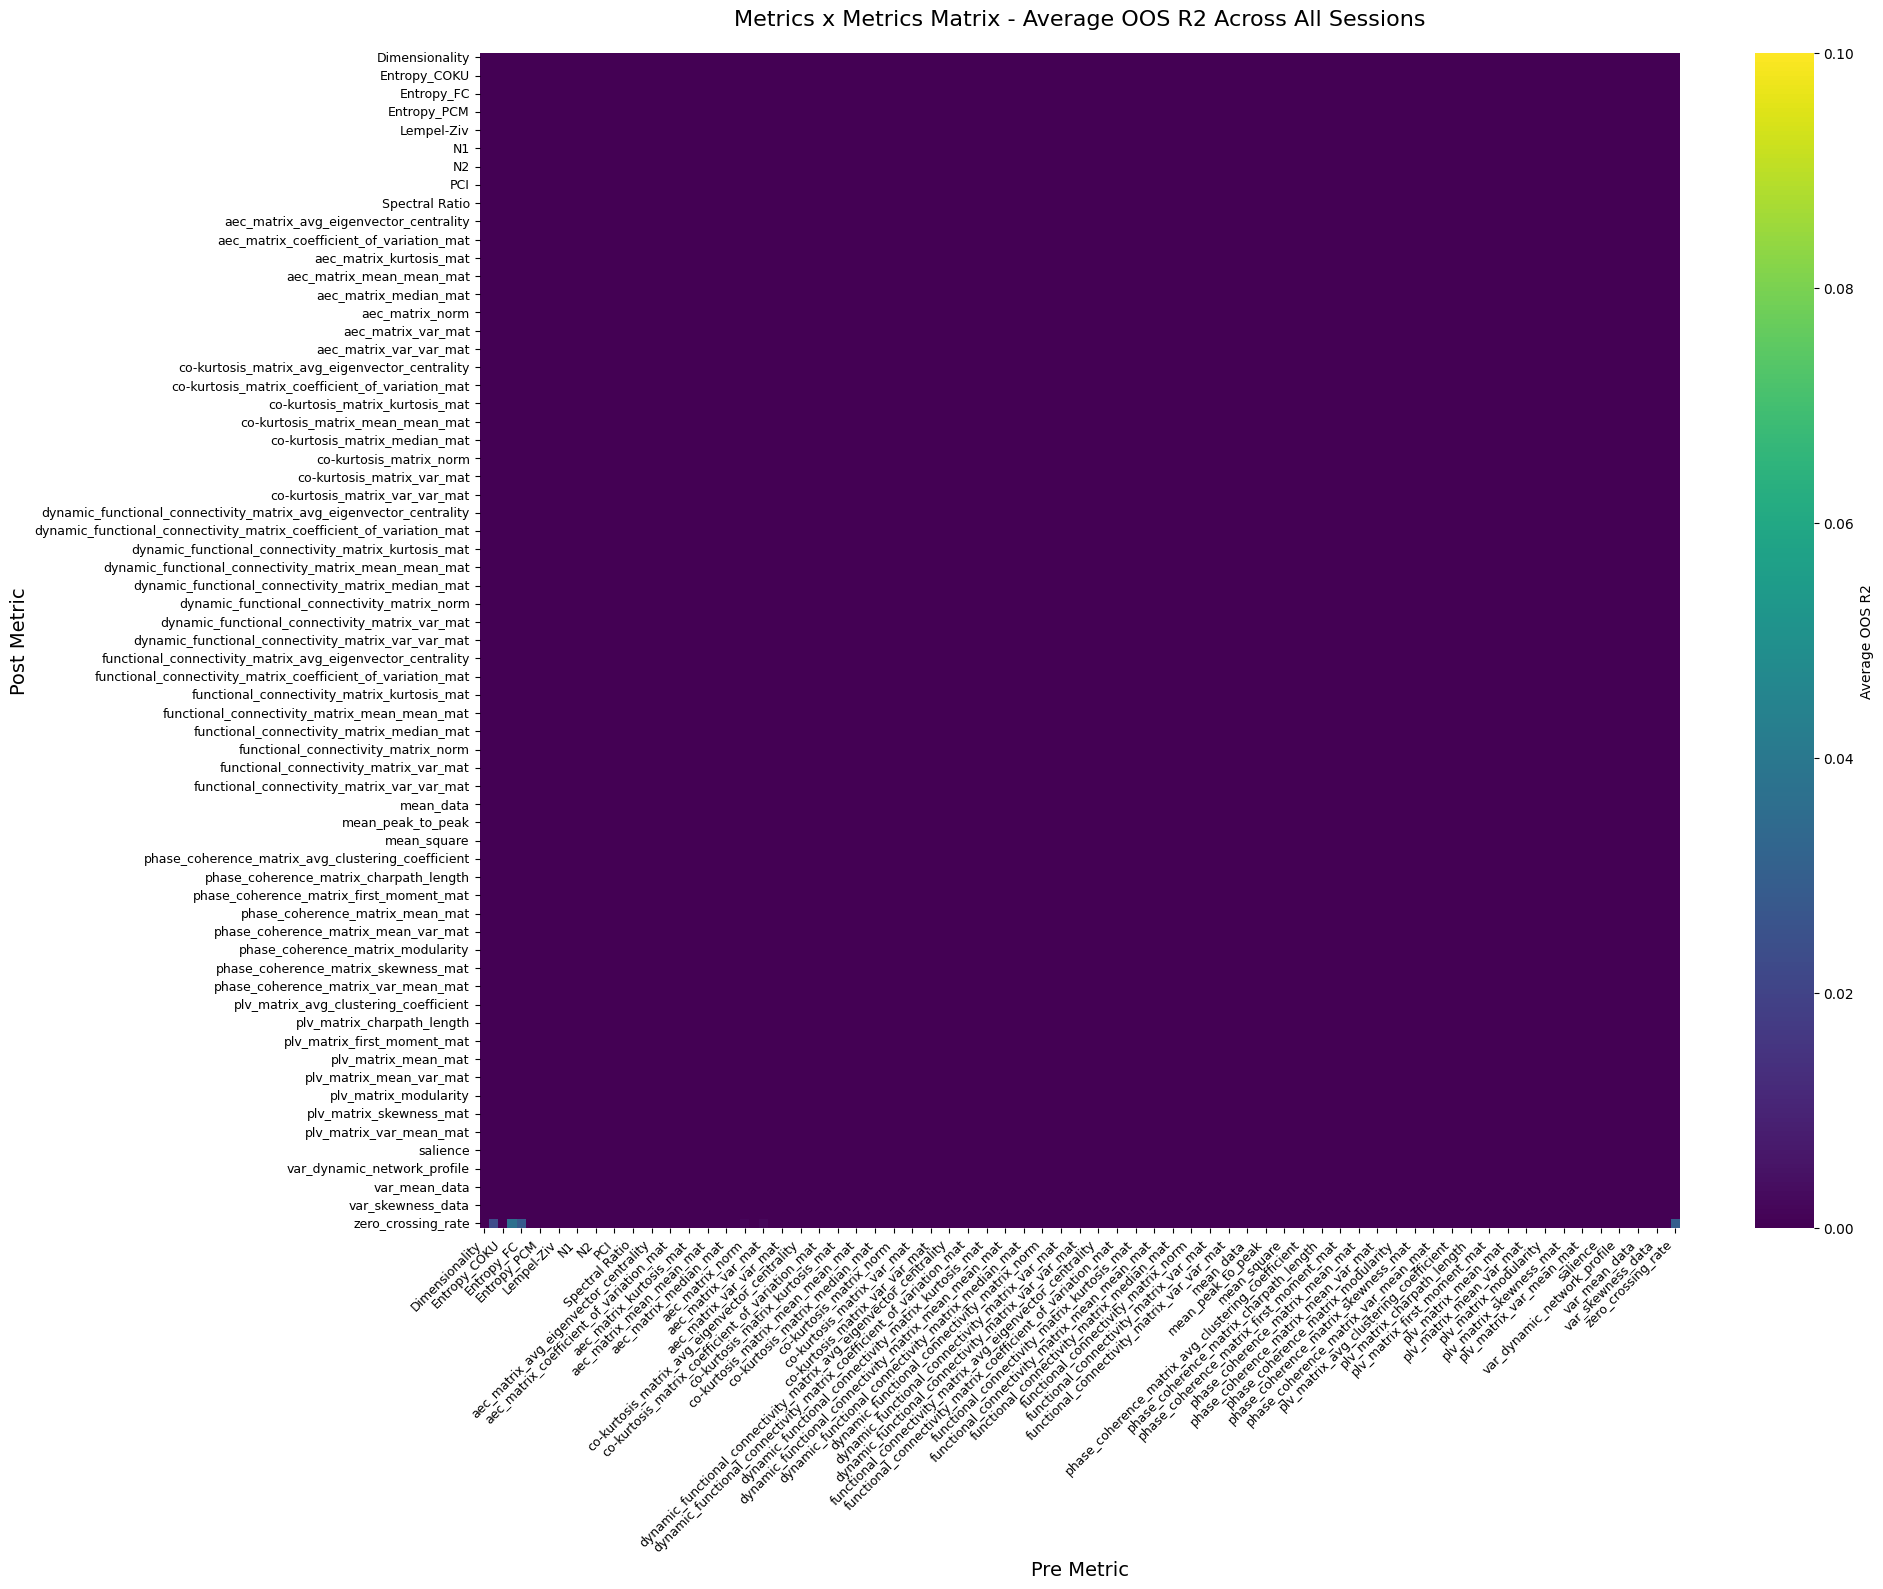

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create figure with appropriate size
plt.figure(figsize=(20, 16))

# Transpose matrix so pre_metric is on x-axis and post_metric is on y-axis
metrics_matrix_transposed = metrics_matrix.T

# Create heatmap
sns.heatmap(metrics_matrix_transposed, cmap='viridis', 
            cbar_kws={'label': 'Average OOS R2'},vmin=0,vmax=0.1)

plt.title('Metrics x Metrics Matrix - Average OOS R2 Across All Sessions', fontsize=16, pad=20)
plt.xlabel('Pre Metric', fontsize=14)
plt.ylabel('Post Metric', fontsize=14)
plt.xticks(fontsize=9, rotation=45, ha='right')
plt.yticks(fontsize=9, rotation=0)
plt.tight_layout()
plt.show()

## Within-Sample Correlation for Zero Crossing Rate (Pre vs Post)
Get the average within_sample_corr for pre vs post zero_crossing_rate metric across all sessions.

In [18]:
# Filter for zero_crossing_rate pre vs post
zcr_filter = (df['pre_metric'] == 'zero_crossing_rate') & (df['post_metric'] == 'zero_crossing_rate')
zcr_data = df[zcr_filter]

# Calculate average within_sample_corr across all sessions
avg_within_sample_corr = zcr_data['within_sample_corr'].mean()

print(f"Average within_sample_corr for pre vs post zero_crossing_rate: {avg_within_sample_corr:.4f}")

Average within_sample_corr for pre vs post zero_crossing_rate: 0.4669


## Top 20 Highest OOS R2 Values with Within-Sample Correlation
Get the 20 metric pairs with highest average oos_r2 and their corresponding within_sample_corr.

In [21]:
# Group by pre_metric and post_metric, calculate means for both oos_r2 and within_sample_corr
top_pairs = df.groupby(['pre_metric', 'post_metric']).agg({
    'oos_r2': 'mean',
    'within_sample_corr': 'mean'
}).reset_index()

# Sort by oos_r2 in descending order and get top 20
top_20_pairs = top_pairs.nlargest(50, 'oos_r2')

print("Top 20 Highest OOS R2 Values (session-averaged) with Within-Sample Correlation:\n")
print(top_20_pairs.to_string(index=False))

Top 20 Highest OOS R2 Values (session-averaged) with Within-Sample Correlation:

                                                       pre_metric                                         post_metric    oos_r2  within_sample_corr
                                                      Entropy_DFC                                  zero_crossing_rate  0.036702            0.470966
                                               zero_crossing_rate                                  zero_crossing_rate  0.029948            0.466863
                                                       Entropy_FC                                  zero_crossing_rate  0.027971            0.453865
                                                      Entropy_AEC                                  zero_crossing_rate  0.022668            0.433051
                                               aec_matrix_var_mat                                  zero_crossing_rate  0.001767           -0.407690
                               

In [22]:
top_20_pairs

,pre_metric,post_metric,oos_r2,within_sample_corr
515,Entropy_DFC,zero_crossing_rate,0.036702,0.470966
16640,zero_crossing_rate,zero_crossing_rate,0.029948,0.466863
644,Entropy_FC,zero_crossing_rate,0.027971,0.453865
257,Entropy_AEC,zero_crossing_rate,0.022668,0.433051
3998,aec_matrix_var_mat,zero_crossing_rate,0.001767,-0.407690
3740,aec_matrix_norm,zero_crossing_rate,0.001374,-0.419875
15600,salience,salience,0.000252,0.540243
7094,dynamic_functional_connectivity_matrix_kurtosi...,zero_crossing_rate,-0.006127,0.430638
15608,salience,zero_crossing_rate,-0.010108,-0.456942
2063,Power_Shannon_Entropy,zero_crossing_rate,-0.010932,0.419501
